<a href="https://colab.research.google.com/github/hindxb/FDS/blob/main/Notebooks/Project/FDS_Prediction_GRU_and_Visualization_nomap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction and Visualization

By Hind Alzarooni U25102248

## GRU Prediction and Map Visualization Pipeline

In this section the GRU model is loaded and a prediction is made on it, then the traffic data is prepared to visualize the generated speed values, segments, colors indicating congesion. The map is interactive allowing to hover over the segments for more information.

### Pipeline Flow

`Load cleaned traffic data + segment coordinates`  
⬇️  
`Load trained GRU model`  
⬇️  
`Preprocess time and segment data`  
⬇️  
`Create temporal, lag, rolling, and speed-difference features`  
⬇️  
`Split data by segment and scale features`  
⬇️  
`Create 24-step input sequences`  
⬇️  
`Predict traffic speed using GRU`  
⬇️  
`Convert predictions back to original speed scale`  
⬇️  
`Merge predictions with road coordinates`  
⬇️  
`Visualize predicted speeds using Folium map`

### Visualization Summary

The predicted traffic speeds are displayed on an interactive Folium map using CartoDB Positron tiles and every road segment is drawn using `PolyLine`, and colors indicate traffic condition:

- Red: slow traffic  
- Orange: moderate traffic  
- Green: free-flow traffic  

A dropdown menu allows predictions to be viewed at different timestamps.

In [ ]:

# 0. IMPORTS + MOUNT DRIVE
# numpy: numerical computations
# pandas: data loading and manipulation
# matplotlib: plotting results and analysis
# folium: interactive map visualization
# ipywidgets: interactive controls (dropdowns, buttons)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import ipywidgets as widgets


# IPython display: used to render outputs and update maps dynamically
# Google Drive: mount to access datasets and saved models
# MinMaxScaler: scales features for model input
# load_model: loads the trained GRU model
from IPython.display import display, clear_output
from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model

drive.mount('/content/drive')



# 1. LOAD DATASETS
# =========================================================

#The path to the dataset
traffic_file_path = '/content/drive/MyDrive/datasets/chicago_traffic_imputed.csv'

#The path to the file containing all the segment info summary
segment_file_path = '/content/drive/MyDrive/datasets/chicago_segments.xlsx'

#Reading from the csv and excel files
df_raw = pd.read_csv(traffic_file_path)
segments_df = pd.read_excel(segment_file_path)

print("Traffic shape:", df_raw.shape)
print("Segments shape:", segments_df.shape)



# 2. LOAD SAVED MODEL
# =========================================================

#Loading the previously saved model so that we can make our predictions
model = load_model('/content/drive/MyDrive/datasets/GRU_model.keras')

print("GRU model loaded successfully")


# 3. PREPROCESSING + FEATURE ENGINEERING
# =========================================================

# Convert TIME to datetime and remove invalid timestamps
# Sort data by segment and time to preserve temporal order
df_raw['TIME'] = pd.to_datetime(df_raw['TIME'], dayfirst=True, errors='coerce')
df_raw = df_raw.dropna(subset=['TIME']).copy()
df_raw = df_raw.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)


# Filter out segments with insufficient data for sequence modeling
# (ensures enough history for GRU input)
min_rows_per_segment = 60
segment_sizes = df_raw.groupby('SEGMENT_ID').size()
valid_segments = segment_sizes[segment_sizes >= min_rows_per_segment].index
df_raw = df_raw[df_raw['SEGMENT_ID'].isin(valid_segments)].copy()


# Extract temporal features:
# - HOUR and DAY_OF_WEEK
# - Binary indicators: weekend and rush hour
df_raw['HOUR'] = df_raw['TIME'].dt.hour
df_raw['DAY_OF_WEEK'] = df_raw['TIME'].dt.dayofweek
df_raw['is_weekend'] = df_raw['DAY_OF_WEEK'].isin([5, 6]).astype(int)
df_raw['is_rush_hour'] = df_raw['HOUR'].isin([7, 8, 9, 16, 17, 18]).astype(int)


# Apply cyclical encoding to capture periodic time patterns
# (hour and day of week represented using sin/cos)
df_raw['hour_sin'] = np.sin(2 * np.pi * df_raw['HOUR'] / 24)
df_raw['hour_cos'] = np.cos(2 * np.pi * df_raw['HOUR'] / 24)
df_raw['dow_sin'] = np.sin(2 * np.pi * df_raw['DAY_OF_WEEK'] / 7)
df_raw['dow_cos'] = np.cos(2 * np.pi * df_raw['DAY_OF_WEEK'] / 7)


# Select relevant columns for modeling
# (traffic, temporal, and target features)
candidate_cols = [
    'TIME', 'SEGMENT_ID', 'SPEED_FILLED',
    'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH',
    'SPEED_WAS_MISSING',
    'DIRECTION',
    'is_weekend', 'is_rush_hour',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]


# Convert all required columns to numeric format
# (ensures compatibility with machine learning models)
existing_cols = [col for col in candidate_cols if col in df_raw.columns]
df_model = df_raw[existing_cols].copy()


numeric_cols = [
    'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH',
    'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

for col in numeric_cols:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Handle missing values:
# - Create missing indicators for BUS_COUNT and MESSAGE_COUNT
# - Replace missing values with 0
# - Ensure SPEED_WAS_MISSING is properly filled

if 'BUS_COUNT' in df_model.columns:
    df_model['BUS_COUNT_MISSING'] = df_model['BUS_COUNT'].isna().astype(int)
    df_model['BUS_COUNT'] = df_model['BUS_COUNT'].fillna(0)

if 'MESSAGE_COUNT' in df_model.columns:
    df_model['MESSAGE_COUNT_MISSING'] = df_model['MESSAGE_COUNT'].isna().astype(int)
    df_model['MESSAGE_COUNT'] = df_model['MESSAGE_COUNT'].fillna(0)

if 'SPEED_WAS_MISSING' in df_model.columns:
    df_model['SPEED_WAS_MISSING'] = df_model['SPEED_WAS_MISSING'].fillna(0)

df_model = df_model.dropna(subset=['SPEED_FILLED']).copy()

if 'DIRECTION' in df_model.columns:
    df_model['DIRECTION'] = df_model['DIRECTION'].astype(str)
    df_model = pd.get_dummies(df_model, columns=['DIRECTION'], drop_first=True)

df_model = df_model.dropna(subset=['TIME', 'SEGMENT_ID', 'SPEED_FILLED']).reset_index(drop=True)

df = df_model.copy()
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)


# 4. LAG / ROLLING FEATURES
# =========================================================

# Create lag features (previous speed values)
# Captures historical traffic patterns for each segment
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'speed_lag_{lag}'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].shift(lag)

# Compute average speed per segment using only training portion
# Helps model learn typical behavior of each road
train_mask = df.groupby('SEGMENT_ID')['TIME'].transform(lambda x: x <= x.quantile(0.8))
segment_mean_train = df[train_mask].groupby('SEGMENT_ID')['SPEED_FILLED'].mean()
df['segment_speed_mean'] = df['SEGMENT_ID'].map(segment_mean_train)

# Encode month as cyclical feature (seasonality)
df['month_sin'] = np.sin(2 * np.pi * df['TIME'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['TIME'].dt.month / 12)

# Rolling mean (short-term trend)
# Average of last 6 speeds (excluding current value)
df['speed_roll_mean_6'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=2).mean()
)

# Rolling standard deviation (traffic variability)
df['speed_roll_std_6'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=2).std()
)

# Rolling mean (longer-term trend)
df['speed_roll_mean_12'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(
    lambda x: x.shift(1).rolling(12, min_periods=4).mean()
)

# Speed difference features (trend direction)
# Measures how speed is changing over time
df['speed_diff_1'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(1)
df['speed_diff_3'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(3)

# Collect all lag/rolling/diff features
lag_cols = [f'speed_lag_{l}' for l in [1, 2, 3, 6, 12, 24]] + [
    'speed_roll_mean_6',
    'speed_roll_std_6',
    'speed_roll_mean_12',
    'speed_diff_1',
    'speed_diff_3'
]

# Remove rows without enough historical data
# (early rows don’t have lag values yet)
df = df.dropna(subset=lag_cols).reset_index(drop=True)

print("Shape after feature engineering:", df.shape)


# 5. TRAIN / TEST SPLIT + SCALING
# =========================================================

sequence_length = 24          # number of past timesteps used for prediction
split_ratio = 0.8            # 80% of data used for training

train_parts = []             # store training data per segment
test_parts = []              # store testing data per segment


# Split each segment separately to preserve temporal order
for segment in df['SEGMENT_ID'].unique():
    segment_df = df[df['SEGMENT_ID'] == segment].sort_values('TIME').copy()
    n = len(segment_df)

    split_idx = int(n * split_ratio)  # define split point (80%)

    # Ensure enough data exists for sequence creation
    if split_idx <= sequence_length or (n - split_idx) <= sequence_length:
        continue

    # First 80% : training, last 20% : testing
    train_parts.append(segment_df.iloc[:split_idx].copy())
    test_parts.append(segment_df.iloc[split_idx:].copy())

# Combine all segments into final datasets
train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
test_df = pd.concat(test_parts, axis=0).reset_index(drop=True)

# Define input features (exclude time, segment ID, and target)
feature_cols = [col for col in df.columns if col not in ['TIME', 'SEGMENT_ID', 'SPEED_FILLED']]

# Define target variable
target_col = 'SPEED_FILLED'

# Initialize scalers for features and target
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Scale features (fit on training, apply to test)
train_df[feature_cols] = feature_scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = feature_scaler.transform(test_df[feature_cols])

# Scale target variable
train_df[[target_col]] = target_scaler.fit_transform(train_df[[target_col]])
test_df[[target_col]] = target_scaler.transform(test_df[[target_col]])

print("Scaling done")
print("Number of features:", len(feature_cols))



# 6. CREATE TEST SEQUENCES WITH TIME + SEGMENT INFO
# =========================================================

#Converts test data into sequences for prediction
#Also stores metadata (segment ID and prediction time) for later use (e.g., mapping)
#X = input sequences, y = targets, meta = extra info
def create_sequences_with_metadata(data, feature_cols, target_col, sequence_length):
    X, y, meta = [], [], []

    # Process each road segment separately
    for segment in data['SEGMENT_ID'].unique():
        segment_df = data[data['SEGMENT_ID'] == segment].sort_values('TIME').copy()

        X_values = segment_df[feature_cols].values
        y_values = segment_df[target_col].values

        # Create sequences using sliding window
        for i in range(sequence_length, len(segment_df)):
            X.append(X_values[i-sequence_length:i])
            y.append(y_values[i])

            #Stores the metadata for each preidiction
            meta.append({
                'SEGMENT_ID': segment,
                'PREDICTION_TIME': segment_df.iloc[i]['TIME']
            })

    return np.array(X), np.array(y), pd.DataFrame(meta)


#Then we generate the test sequences
X_test, y_test, meta_df = create_sequences_with_metadata(
    test_df,
    feature_cols,
    target_col,
    sequence_length
)

print("X_test shape:", X_test.shape)



# 7. PREDICT SPEEDS
# Generate predictions using the trained GRU model
# =========================================================
pred_scaled = model.predict(X_test)

# Convert scaled values back to original speed units
# Combine predictions with metadata (segment ID and time)
actual_speed = target_scaler.inverse_transform(y_test.reshape(-1, 1))
predicted_speed = target_scaler.inverse_transform(pred_scaled)

# Store actual and predicted speeds in a DataFrame
predictions_df = meta_df.copy()
predictions_df['Actual_Speed'] = actual_speed.flatten()
predictions_df['Predicted_Speed'] = predicted_speed.flatten()

print("Predictions created:", predictions_df.shape)

# Save results to CSV for visualization and further analysis
predictions_df.to_csv(
    '/content/drive/MyDrive/datasets/gru_predictions_for_map.csv',
    index=False
)

print("Predictions saved")



# 8. MERGE PREDICTIONS WITH SEGMENT COORDINATES
# =========================================================

# Convert SEGMENT_ID to numeric for consistency
# Merge predictions with segment coordinate data
segments_df['SEGMENT_ID'] = pd.to_numeric(segments_df['SEGMENT_ID'], errors='coerce')
predictions_df['SEGMENT_ID'] = pd.to_numeric(predictions_df['SEGMENT_ID'], errors='coerce')

map_df = predictions_df.merge(
    segments_df,
    on='SEGMENT_ID',
    how='inner'
)

coord_cols = [
    'START_LATITUDE', 'START_LONGITUDE',
    'END_LATITUDE', 'END_LONGITUDE'
]

# Ensure latitude and longitude columns are numeric
# Remove rows with missing coordinates
for col in coord_cols:
    map_df[col] = pd.to_numeric(map_df[col], errors='coerce')

map_df = map_df.dropna(subset=coord_cols).copy()

# Final dataset ready for map visualization
print("Map dataframe shape:", map_df.shape)
display(map_df.head())



# 9. COLOR FUNCTION
# speed below 15 mph is considered high congestion (red)
# speed below 25 mph is considered medium congestion (orange)
# any other speed in mph is considered low congestion (green)
# =========================================================
def speed_color(speed):
    if speed < 15:
        return 'red'
    elif speed < 25:
        return 'orange'
    else:
        return 'green'



# 10. INTERACTIVE MAP
# =========================================================
unique_times = sorted(map_df['PREDICTION_TIME'].dropna().unique())

# reduce dropdown size by taking every 6th timestamp if too many
dropdown_times = unique_times[::6]

#provides a dropdown to select time
#later in the 3rd block this is enhanced so that you can also select the segments
time_dropdown = widgets.Dropdown(
    options=dropdown_times,
    description='Time:',
    layout=widgets.Layout(width='500px')
)

output = widgets.Output()

#draws the details of the map based on the time you choose
def draw_traffic_map(selected_time):
    filtered = map_df[map_df['PREDICTION_TIME'] == selected_time].copy()

    #in case there is no data available for the selected time
    if filtered.empty:
        print("No data available for this time.")
        return

    #finds the center of the segment
    center_lat = filtered[['START_LATITUDE', 'END_LATITUDE']].mean().mean()
    center_lon = filtered[['START_LONGITUDE', 'END_LONGITUDE']].mean().mean()

    #uses folium to create the map using cartod positron
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='cartodbpositron'
    )


    #if you click on a segment the below information will pop up
    # segment ID, street name, from and to street, direction
    # predicted speed, the actual speed and the time of the prediction
    for _, row in filtered.iterrows():
        color = speed_color(row['Predicted_Speed'])

        popup_text = f"""
        <b>Segment ID:</b> {row['SEGMENT_ID']}<br>
        <b>Street:</b> {row.get('STREET', '')}<br>
        <b>From:</b> {row.get('FROM_STREET', '')}<br>
        <b>To:</b> {row.get('TO_STREET', '')}<br>
        <b>Direction:</b> {row.get('DIRECTION', '')}<br>
        <b>Predicted Speed:</b> {row['Predicted_Speed']:.2f} mph<br>
        <b>Actual Speed:</b> {row['Actual_Speed']:.2f} mph<br>
        <b>Time:</b> {row['PREDICTION_TIME']}
        """

        #draws the segment and puts the color on them based on the predicted speed
        folium.PolyLine(
            locations=[
                [row['START_LATITUDE'], row['START_LONGITUDE']],
                [row['END_LATITUDE'], row['END_LONGITUDE']]
            ],
            color=color,
            weight=6,
            opacity=0.85,
            popup=folium.Popup(popup_text, max_width=300)
        ).add_to(m)

    #adjustments like position and colors
    legend_html = """
    <div style="
        position: fixed;
        bottom: 50px;
        left: 50px;
        width: 170px;
        height: 110px;
        background-color: white;
        border:2px solid grey;
        z-index:9999;
        font-size:14px;
        padding: 10px;
    ">
    <b>Predicted Speed</b><br>
    <span style="color:red;">●</span> Slow (&lt; 15 mph)<br>
    <span style="color:orange;">●</span> Medium (15–25 mph)<br>
    <span style="color:green;">●</span> Fast (≥ 25 mph)
    </div>
    """

    #display the map with details
    m.get_root().html.add_child(folium.Element(legend_html))
    display(m)

#whenever a new time is selected from the drop down and applied
#this will refresh the map to show the results
def on_time_change(change):
    with output:
        clear_output(wait=True)
        draw_traffic_map(change['new'])

#shows the drop down of the time so you can select from it
time_dropdown.observe(on_time_change, names='value')

display(time_dropdown)
display(output)

with output:
    draw_traffic_map(time_dropdown.value)

The output thad to be cleared due to Github issue not showing widget metadata, hence i presented the output in the image below. you may download and run the code

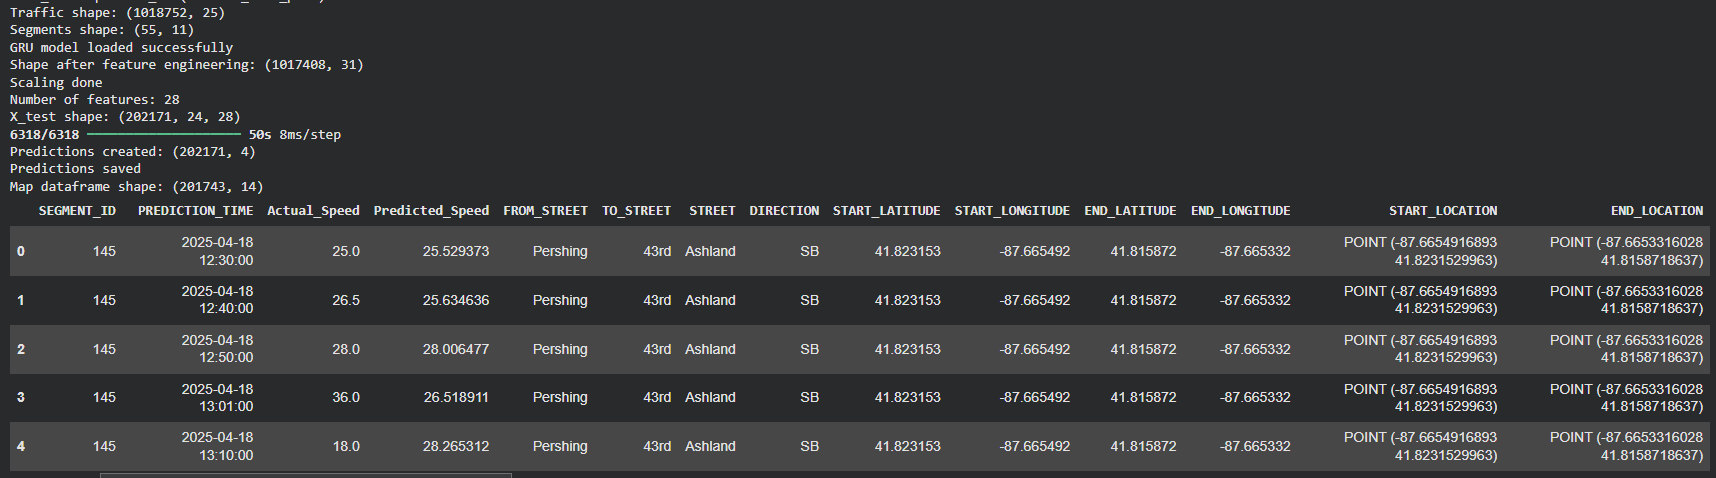

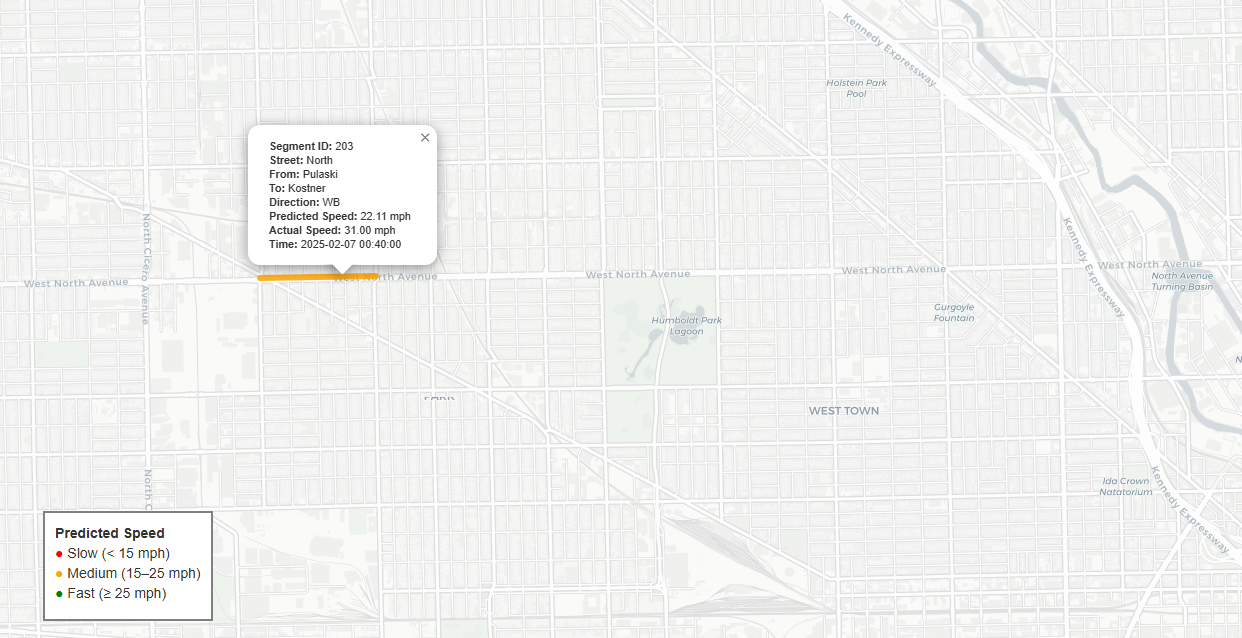

In the below code we are just validating the prediction file to see if the prediction has been applied properly

In [ ]:
#Shows how many segments were predicted and how many segments are shown on the map
print("Predictions segments:", predictions_df['SEGMENT_ID'].nunique())
print("Coordinate segments :", segments_df['SEGMENT_ID'].nunique())
print("Map segments        :", map_df['SEGMENT_ID'].nunique())

#shows how many possible time selections can we have on the map based on the number of predictions
print("\nPredictions time count:", predictions_df['PREDICTION_TIME'].nunique())
print("Map time count        :", map_df['PREDICTION_TIME'].nunique())

#The samples of segment IDs which prediction was applied on
print("\nSample prediction segment IDs:")
print(predictions_df['SEGMENT_ID'].drop_duplicates().head(20).tolist())

#Segment IDs whos coordinates are saved and used
print("\nSample coordinate segment IDs:")
print(segments_df['SEGMENT_ID'].drop_duplicates().head(20).tolist())

#segments that can be displayed on the map
print("\nSample map segment IDs:")
print(map_df['SEGMENT_ID'].drop_duplicates().head(20).tolist())

Predictions segments: 56
Coordinate segments : 55
Map segments        : 55

Predictions time count: 4901
Map time count        : 4901

Sample prediction segment IDs:
[144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 166]

Sample coordinate segment IDs:
[145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 166, 168]

Sample map segment IDs:
[145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 166, 168]


## Interactive Traffic Visualization

### What this section does
- Displays predicted traffic speeds on a city map  
- Uses color to represent congestion levels  
- Allows filtering by time and road segments  

---

### Visualization Flow

Predicted Speeds + Coordinates  
        ↓  
Filter by Time  
        ↓  
Select Road Segments  
        ↓  
Map Rendering (Folium)  
        ↓  
Color-coded Traffic Lines  
        ↓  
Interactive Exploration  

---

### User Controls
- Time Dropdown → view different timestamps  
- Segment Selector → focus on specific roads  
- Buttons → select all / clear / update  

---

### Speed Interpretation
- Red (< 20 mph) → High congestion  
- Yellow (20–30 mph) → Moderate traffic  
- Green (> 30 mph) → Free flow  

In [ ]:

# INTERACTIVE MAP WITH TIME DROPDOWN + MULTI-SEGMENT SELECT
# Import visualization and interaction libraries:
# - folium: map visualization
# - ipywidgets: interactive UI controls
# - display utilities: dynamic output updates
# =========================================================
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import output as colab_output

# Convert prediction time to datetime format
# Remove rows with missing time, coordinates, or predicted speed
# Ensures clean and valid data for map visualization
colab_output.enable_custom_widget_manager()

map_df['PREDICTION_TIME'] = pd.to_datetime(map_df['PREDICTION_TIME'], errors='coerce')

map_df = map_df.dropna(subset=[
    'PREDICTION_TIME',
    'START_LATITUDE', 'START_LONGITUDE',
    'END_LATITUDE', 'END_LONGITUDE',
    'Predicted_Speed'
]).copy()



# OPTIONS
# =========================================================

# Count number of segments available per timestamp
# Used to show how much data exists at each time point
time_counts = (
    map_df.groupby('PREDICTION_TIME')['SEGMENT_ID']
    .nunique()
    .reset_index(name='segments_available')
    .sort_values('PREDICTION_TIME')
)


time_options = [
    (f"{row.PREDICTION_TIME} | {row.segments_available} segments", row.PREDICTION_TIME)
    for _, row in time_counts.iterrows()
]

# reduce time options if too many
time_options = time_options[::12] if len(time_options) > 150 else time_options

segment_options = sorted(map_df['SEGMENT_ID'].dropna().unique().astype(int).tolist())


# Create dropdown options displaying time + number of segments
# Improves user understanding of data availability
time_dropdown = widgets.Dropdown(
    options=time_options,
    description='Time:',
    layout=widgets.Layout(width='800px')
)


# Reduce number of time options if too many
# Prevents UI from becoming slow or cluttered
# Extract unique segment IDs for selection
# Allows user to filter specific road segments
# Create interactive widgets:
# - Time dropdown (select prediction timestamp)
# - Segment selector (multi-select roads)
# - Buttons (select all, clear, update map)
segment_selector = widgets.SelectMultiple(
    options=segment_options,
    value=tuple(segment_options[:10]),
    description='Segments:',
    rows=12,
    layout=widgets.Layout(width='350px')
)

select_all_button = widgets.Button(
    description='Select All',
    button_style='success'
)

clear_button = widgets.Button(
    description='Clear',
    button_style='warning'
)

update_button = widgets.Button(
    description='Update Map',
    button_style='primary'
)

# Create output container to display the map dynamically
map_output = widgets.Output()



# COLOR FUNCTION
# speed below 20 mph is considered high congestion (red)
# speed below 30 mph is considered medium congestion (yellow)
# any other speed in mph is considered low congestion (green)
# =========================================================
def speed_color(speed):
    if speed < 20:
        return 'red'
    elif speed < 30:
        return 'yellow'
    else:
        return 'green'



# DRAW MAP
# =========================================================

# Filter map data by selected prediction time
# Further filter by selected road segments if provided
def draw_traffic_map(selected_time, selected_segments):
    filtered = map_df[map_df['PREDICTION_TIME'] == selected_time].copy()

    if selected_segments:
        selected_segments = list(selected_segments)
        filtered = filtered[filtered['SEGMENT_ID'].isin(selected_segments)].copy()

    # Print selected time and number of displayed segments
    # Stop function if no data is available
    print("Selected time:", selected_time)
    print("Segments shown:", filtered['SEGMENT_ID'].nunique())

    if filtered.empty:
        print("No data available for the selected time/segments.")
        return

    # Calculate map center using average segment coordinates
    # Create Folium map using CartoDB Positron base tiles
    center_lat = filtered[['START_LATITUDE', 'END_LATITUDE']].mean().mean()
    center_lon = filtered[['START_LONGITUDE', 'END_LONGITUDE']].mean().mean()


    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='cartodbpositron'
    )

    bounds = []

    # Loop through each selected road segment:
    # - Get start and end coordinates
    # - Create popup with segment details and speed values
    # - Create tooltip for quick hover information
    # - Draw road segment using Folium PolyLine
    # - Color the segment based on predicted speed
    for _, row in filtered.iterrows():
        start = [row['START_LATITUDE'], row['START_LONGITUDE']]
        end = [row['END_LATITUDE'], row['END_LONGITUDE']]
        bounds.extend([start, end])

        popup_html = f"""
        <div style="font-family: Arial; font-size: 13px; width: 240px;">
            <h4 style="margin-bottom: 6px;">Traffic Segment</h4>
            <b>Segment ID:</b> {row['SEGMENT_ID']}<br>
            <b>Street:</b> {row.get('STREET', '')}<br>
            <b>From:</b> {row.get('FROM_STREET', '')}<br>
            <b>To:</b> {row.get('TO_STREET', '')}<br>
            <b>Direction:</b> {row.get('DIRECTION', '')}<br>
            <hr style="margin: 6px 0;">
            <b>Predicted Speed:</b> {row['Predicted_Speed']:.2f} mph<br>
            <b>Actual Speed:</b> {row['Actual_Speed']:.2f} mph<br>
            <b>Time:</b> {row['PREDICTION_TIME']}<br>
        </div>
        """

        tooltip_text = (
            f"Segment {row['SEGMENT_ID']} | "
            f"{row.get('STREET', '')} | "
            f"{row['Predicted_Speed']:.1f} mph"
        )

        folium.PolyLine(
            locations=[start, end],
            color=speed_color(row['Predicted_Speed']),
            weight=9,
            opacity=0.9,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=tooltip_text
        ).add_to(m)

    # Fit map view to displayed road segments
    # Add speed legend to explain color meanings
    # Display the final interactive map
    if bounds:
        m.fit_bounds(bounds)

    legend_html = """
    <div style="
        position: fixed;
        bottom: 50px;
        left: 50px;
        width: 190px;
        height: 115px;
        background-color: white;
        border:2px solid grey;
        z-index:9999;
        font-size:14px;
        padding: 10px;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    ">
    <b>Predicted Speed</b><br>
    <span style="color:red;">●</span> Slow (&lt; 15 mph)<br>
    <span style="color:gold;">●</span> Medium (15–25 mph)<br>
    <span style="color:green;">●</span> Fast (≥ 25 mph)
    </div>
    """

    m.get_root().html.add_child(folium.Element(legend_html))
    display(m)



# BUTTON ACTIONS
# =========================================================

#The update map button activates when clicked and updates the map
#based on the new selected values
def update_map_clicked(button):
    with map_output:
        clear_output(wait=True)
        draw_traffic_map(
            time_dropdown.value,
            segment_selector.value
        )

#this selects all the segments rather than just some of them being displayed
def select_all_clicked(button):
    segment_selector.value = tuple(segment_options)

#clears all the segments selected
def clear_clicked(button):
    segment_selector.value = tuple()

#implementing the buttons
update_button.on_click(update_map_clicked)
select_all_button.on_click(select_all_clicked)
clear_button.on_click(clear_clicked)



# DISPLAY CONTROLS
# =========================================================

#show the drop down for the time and also segment selector
controls = widgets.VBox([
    time_dropdown,
    widgets.HBox([segment_selector, widgets.VBox([select_all_button, clear_button, update_button])])
])

#display the controls
#display the map
display(controls)
display(map_output)

with map_output:
    draw_traffic_map(time_dropdown.value, segment_selector.value)

The output thad to be cleared due to Github issue not showing widget metadata, hence i presented the output in the image below. you may download and run the code

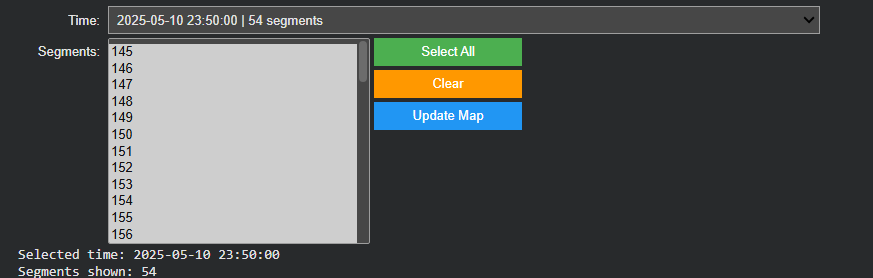

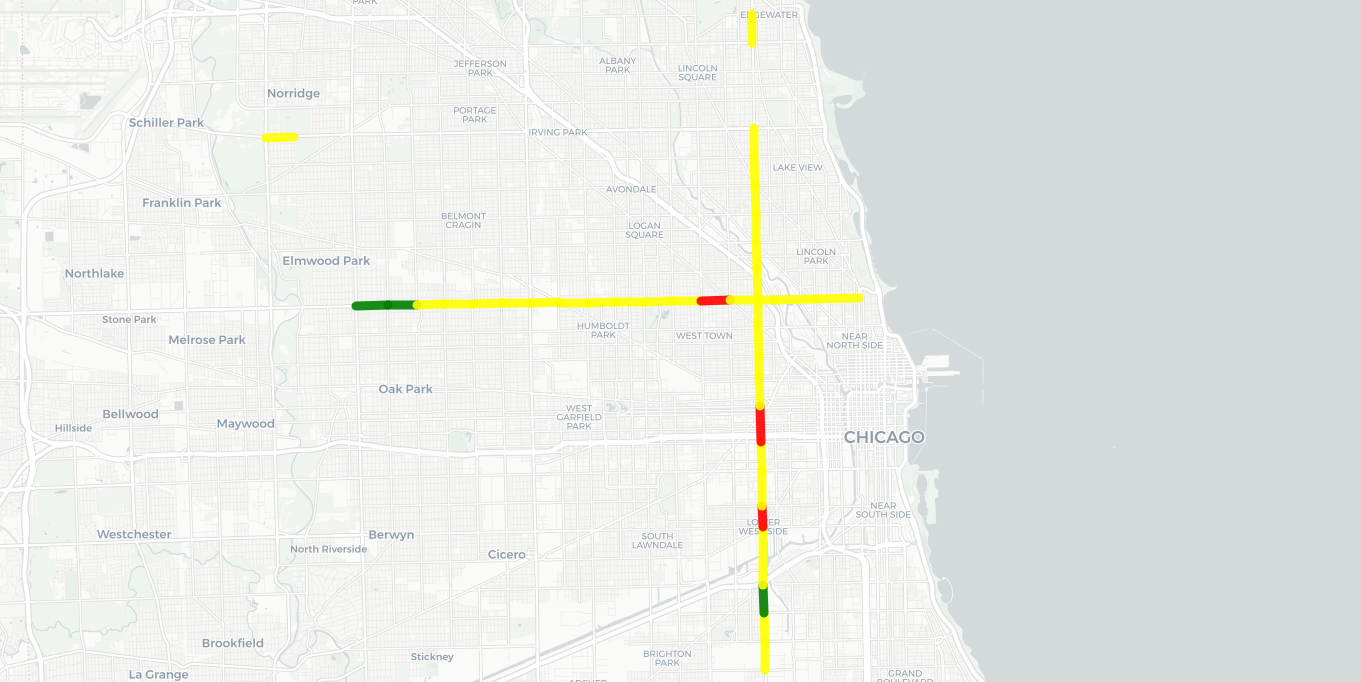